# Finding the limits of logistical regression on this data


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pathlib import Path



# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

## Reading in the data

In [2]:
data_dir = Path('../data')
output_dir = Path('../outputs')

## Scaling the data

## Logistic regression

In [ ]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
ev_ne_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = ev_ne_scaler.fit_transform(X_train)

c_accuracies = []
c_perplexities = []

for c in np.linspace(0.1, 1.0, 50):
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train2):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
            log_model.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(X_test_fold)
            y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_c_accuracies = [np.mean(accs) for accs in c_accuracies]
best_c_index = np.argmax(mean_c_accuracies)
best_c = np.linspace(0.1, 1.0, 50)[best_c_index]
mean_c_perplexities = [np.mean(perps) for perps in c_perplexities]

print(f"Best C: {best_c:.4f} "
      f"with Average Accuracy: {mean_c_accuracies[best_c_index]:.4f} "
      f"and Average Perplexity: {mean_c_perplexities[best_c_index]:.4f}")

Best C: 0.4673 with Average Accuracy: 0.8973 and Average Perplexity: 1.3641


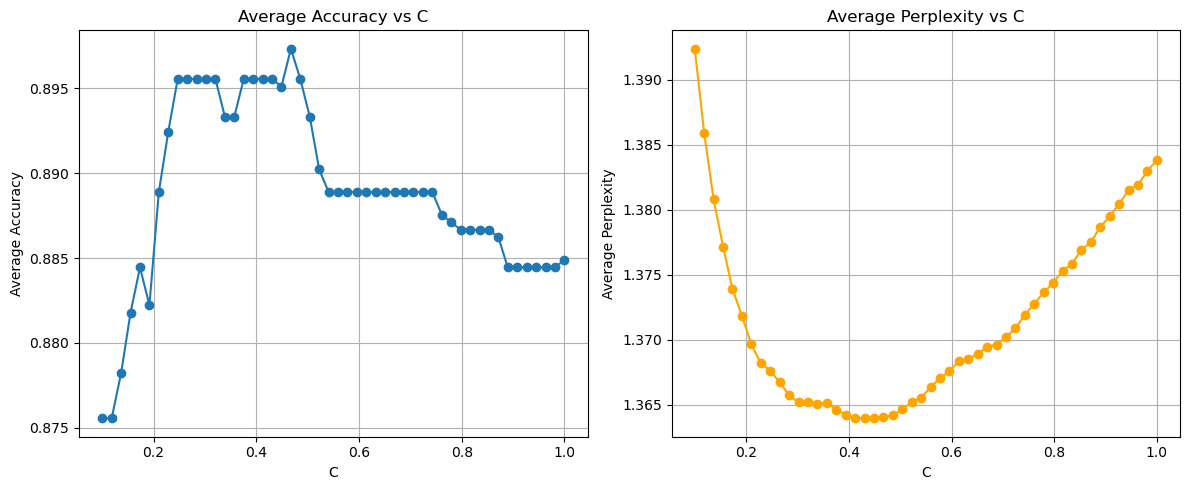

In [28]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.1, 1.0, 50), mean_c_accuracies, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.1, 1.0, 50), mean_c_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

If accuracy and perplexity peak at different C, we can tune two different models.

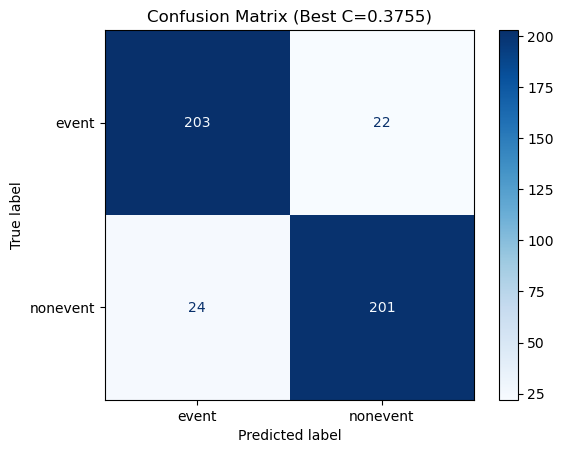

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LogisticRegression(C=best_c, l1_ratio=1, solver='liblinear')
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train2):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
    best_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(best_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Best C={best_c:.4f})")
plt.show()

## Next classifying into I and II

In [57]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
train_df.class4 = train_df.class4.replace({'Ia': 'I', 'Ib':'I'})
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)


I_II_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = I_II_scaler.fit_transform(X_train)

c_accuracies = []
c_perplexities = []

for c in np.linspace(0.01, 0.3, 50):
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train4):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
            log_model.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(X_test_fold)
            y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_c_accuracies_I_II = [np.mean(accs) for accs in c_accuracies]
best_c_index_I_II = np.argmax(mean_c_accuracies_I_II)
best_c_I_II = np.linspace(0.01, 0.3, 50)[best_c_index_I_II]
mean_c_perplexities_I_II = [np.mean(perps) for perps in c_perplexities]

print(f"Best C: {best_c_I_II:.4f} "
      f"with Average Accuracy: {mean_c_accuracies_I_II[best_c_index_I_II]:.4f} "
      f"and Average Perplexity: {mean_c_perplexities_I_II[best_c_index_I_II]:.4f}")

Best C: 0.1698 with Average Accuracy: 0.6542 and Average Perplexity: 1.9096


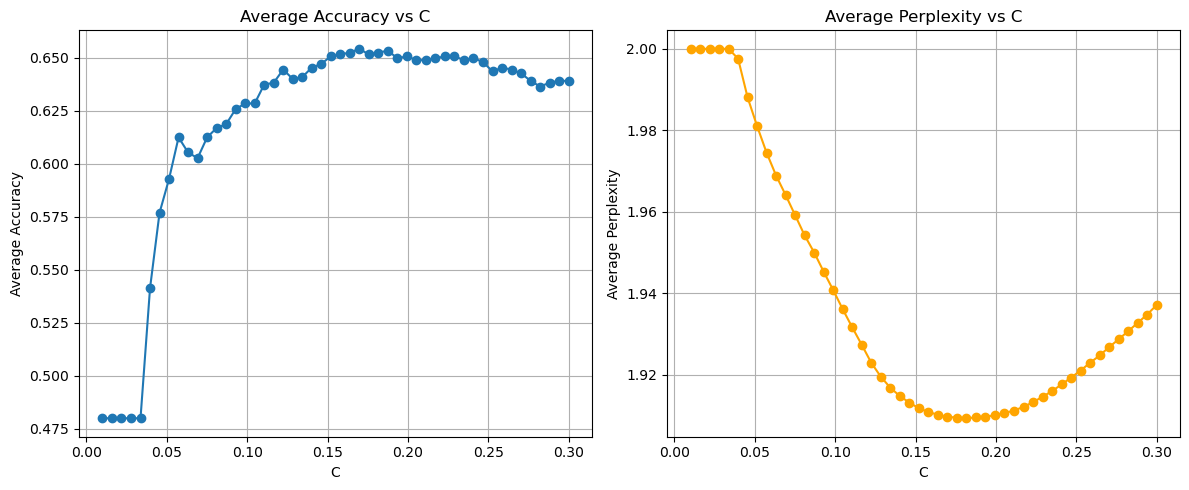

In [58]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.01, 0.3, 50), mean_c_accuracies_I_II, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.01, 0.3, 50), mean_c_perplexities_I_II, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

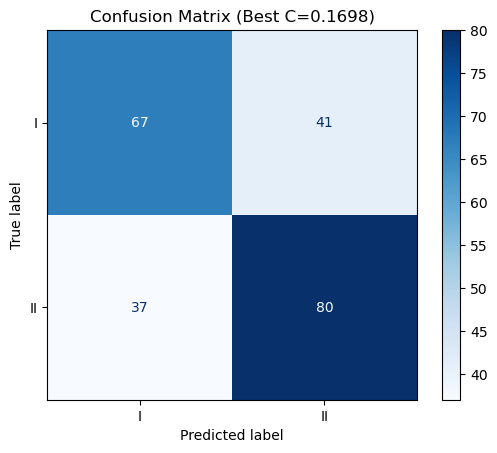

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LogisticRegression(C=best_c_I_II, l1_ratio=1, solver='liblinear')
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    best_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(best_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Best C={best_c:.4f})")
plt.show()

## And then Ia Ib classification

In [64]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
train_df = train_df[train_df['class4'] != 'II']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)


IA_IB_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = IA_IB_scaler.fit_transform(X_train)

c_accuracies = []
c_perplexities = []

for c in np.linspace(0.01, 1.0, 50):
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train4):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
            log_model.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(X_test_fold)
            y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_c_accuracies_IA_IB = [np.mean(accs) for accs in c_accuracies]
best_c_index_IA_IB = np.argmax(mean_c_accuracies_IA_IB)
best_c_IA_IB = np.linspace(0.01, 1.0, 50)[best_c_index_IA_IB]
mean_c_perplexities_IA_IB = [np.mean(perps) for perps in c_perplexities]

print(f"Best C: {best_c_IA_IB:.4f} "
      f"with Average Accuracy: {mean_c_accuracies_IA_IB[best_c_index_IA_IB]:.4f} "
      f"and Average Perplexity: {mean_c_perplexities_IA_IB[best_c_index_IA_IB]:.4f}")

Best C: 0.2120 with Average Accuracy: 0.7743 and Average Perplexity: 1.6885


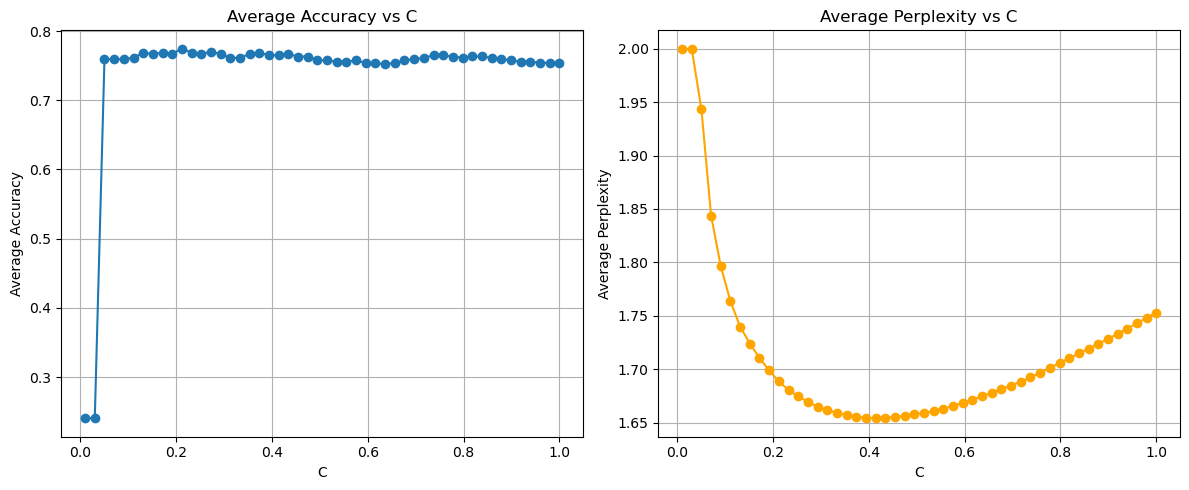

In [65]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.01, 1.0, 50), mean_c_accuracies_IA_IB, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.01, 1.0, 50), mean_c_perplexities_IA_IB, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

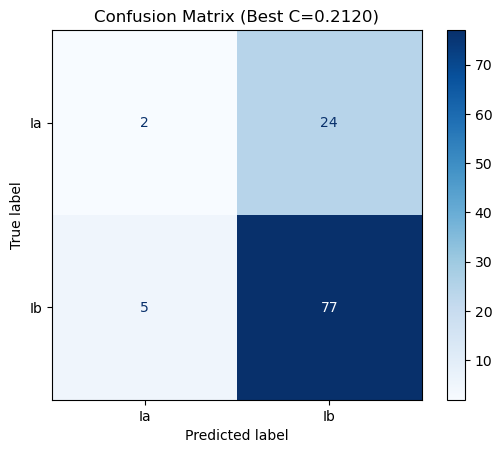

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LogisticRegression(C=best_c_IA_IB, l1_ratio=1, solver='liblinear')
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    best_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(best_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Best C={best_c_IA_IB:.4f})")
plt.show()